In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sridipbasu/india-tech-jobs-2024-2026-salary-and-skills/india_job_market_2024_2026.csv')

df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [4]:
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420
std,18.136741,4.046942,363.989613,0.424994
min,0.800000,1.000000,14.000000,2.500000
25%,6.800000,1.000000,99.000000,3.400000
50%,13.600000,2.000000,185.000000,3.800000
75%,25.600000,3.000000,321.000000,4.100000
max,115.400000,20.000000,2387.000000,4.300000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.nunique()

Job_ID                5000
Job_Title               30
Company                 53
Company_Type             4
Industry                15
City                    17
Location_Tier            3
Experience_Level         5
Job_Type                 4
Work_Mode                3
Salary_LPA             728
Skills_Required       4817
Education_Required       8
Openings                 7
Applicants             989
Company_Rating          19
Date_Posted            697
dtype: int64

--- 💰 Salary Statistics Summary ---
count    5000.000000
mean       19.829440
std        18.136741
min         0.800000
25%         6.800000
50%        13.600000
75%        25.600000
max       115.400000
Name: Salary_LPA, dtype: float64


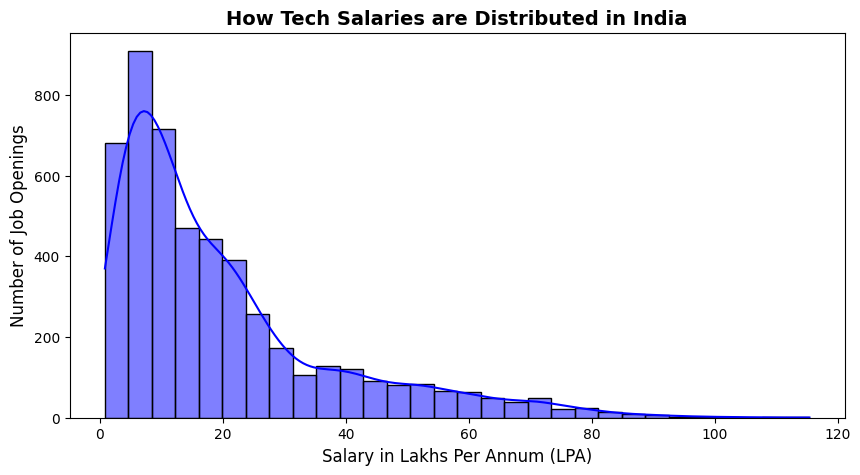

In [7]:
# 1. Calculate the standard mathematical summary statistics of the Salary column
print("--- 💰 Salary Statistics Summary ---")
print(df['Salary_LPA'].describe())

# 2. Set up the size of your graph (10 inches wide, 5 inches tall)
plt.figure(figsize=(10, 5))

# 3. Plot the histogram using the Seaborn library
# x='Salary_LPA' tells it to use our salary column
# kde=True adds a smooth curved line over the bars to show the shape of the data
sns.histplot(data=df, x='Salary_LPA', kde=True, color='blue', bins=30)

# 4. Add titles and labels so the graph is easy to read
plt.title("How Tech Salaries are Distributed in India", fontsize=14, fontweight='bold')
plt.xlabel("Salary in Lakhs Per Annum (LPA)", fontsize=12)
plt.ylabel("Number of Job Openings", fontsize=12)

# 5. Show the plot on the screen
plt.show()

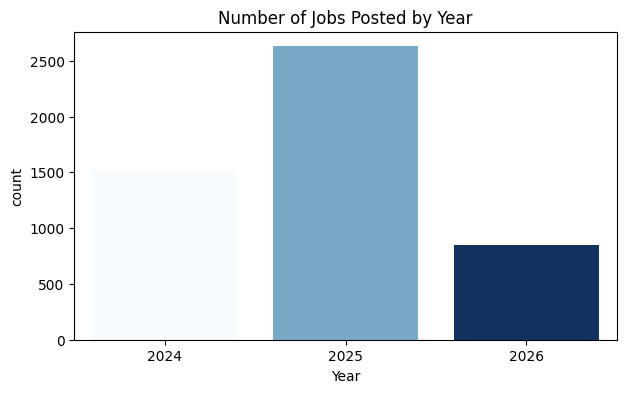

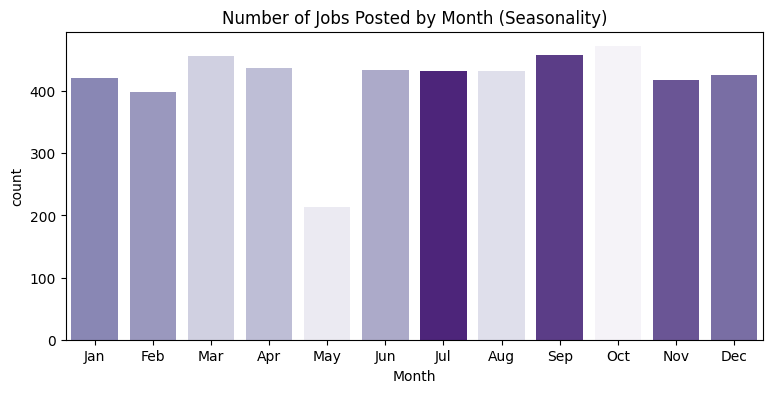

In [9]:
# 1. Convert the Date column into an actual Python date format
df['Date_Posted'] = pd.to_datetime(df['Date_Posted'])

# 2. Extract Year and Month names into separate columns
df['Year'] = df['Date_Posted'].dt.year
df['Month'] = df['Date_Posted'].dt.strftime('%b') # Gives short names like Jan, Feb, Mar

# 3. Create a simple plot for Yearly Hiring Counts (Fixed Warning)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Year', hue='Year', palette='Blues', legend=False)
plt.title('Number of Jobs Posted by Year')
plt.show()

# 4. Create a simple plot for Monthly Hiring Counts (Fixed Warning)
plt.figure(figsize=(9, 4))
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.countplot(data=df, x='Month', order=month_order, hue='Month', palette='Purples', legend=False)
plt.title('Number of Jobs Posted by Month (Seasonality)')
plt.show()

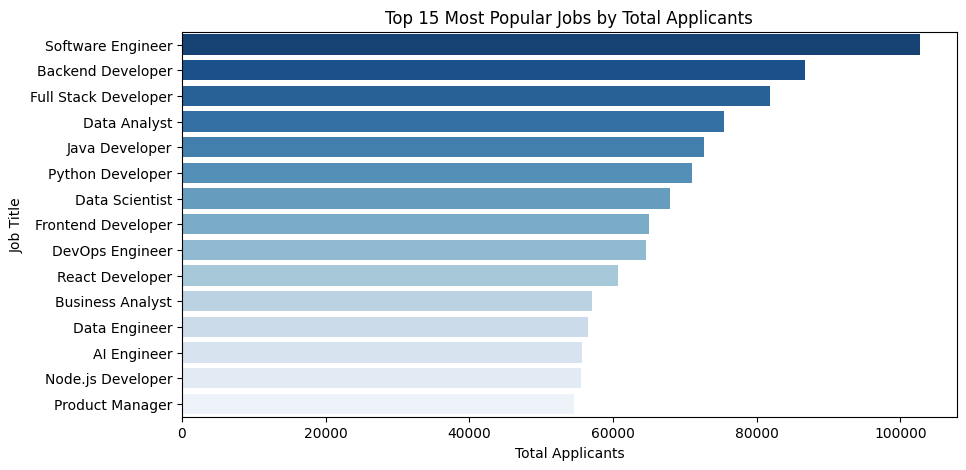

In [10]:
# 1. Group by job title, sum the total applicants, and take the top 15
top_applicants = df.groupby('Job_Title')['Applicants'].sum().sort_values(ascending=False).head(15).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_applicants, x='Applicants', y='Job_Title', hue='Job_Title', palette='Blues_r', legend=False)
plt.title('Top 15 Most Popular Jobs by Total Applicants')
plt.xlabel('Total Applicants')
plt.ylabel('Job Title')
plt.show()

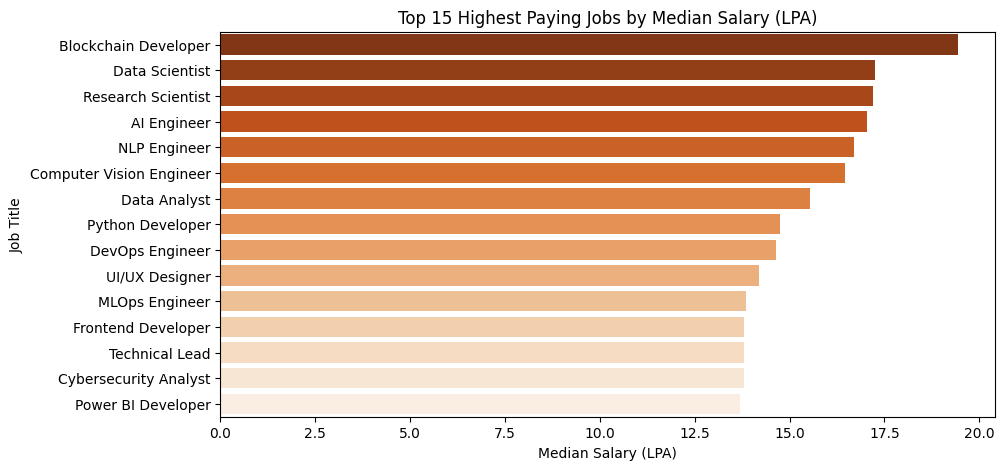

In [11]:
# 1. Group by job title, find the median salary, and take the top 15
top_salaries = df.groupby('Job_Title')['Salary_LPA'].median().sort_values(ascending=False).head(15).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_salaries, x='Salary_LPA', y='Job_Title', hue='Job_Title', palette='Oranges_r', legend=False)
plt.title('Top 15 Highest Paying Jobs by Median Salary (LPA)')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('Job Title')
plt.show()

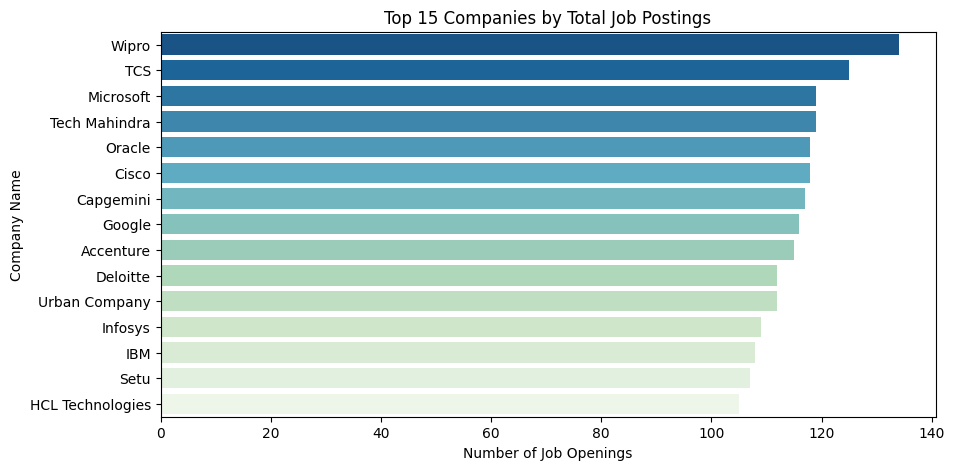

In [12]:
# 1. Count how many times each company appears and take the top 15
top_hiring_companies = df['Company'].value_counts().head(15).reset_index()
top_hiring_companies.columns = ['Company', 'Job_Count']

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_hiring_companies, x='Job_Count', y='Company', hue='Company', palette='GnBu_r', legend=False)
plt.title('Top 15 Companies by Total Job Postings')
plt.xlabel('Number of Job Openings')
plt.ylabel('Company Name')
plt.show()

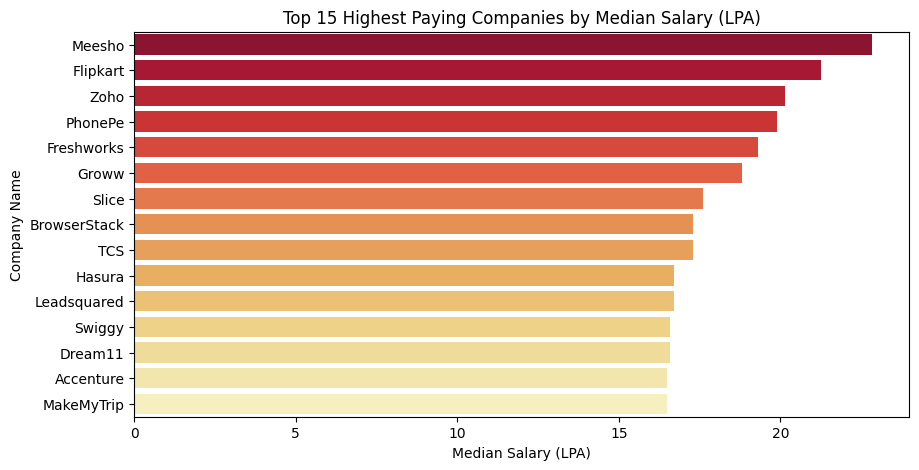

In [13]:
# 1. Group by company, find the median salary, and take the top 15
top_company_salaries = df.groupby('Company')['Salary_LPA'].median().sort_values(ascending=False).head(15).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_company_salaries, x='Salary_LPA', y='Company', hue='Company', palette='YlOrRd_r', legend=False)
plt.title('Top 15 Highest Paying Companies by Median Salary (LPA)')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('Company Name')
plt.show()

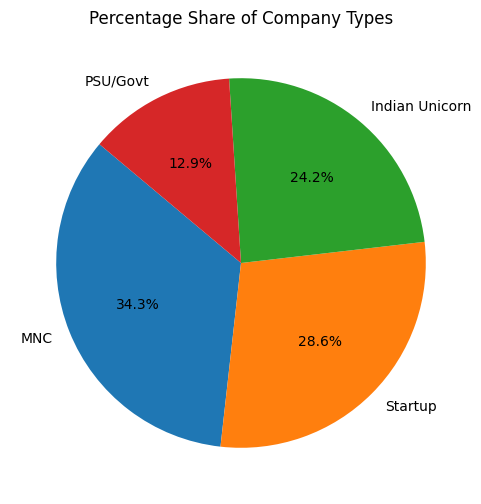

In [14]:
# 1. Count how many times each company type appears
company_counts = df['Company_Type'].value_counts()

# 2. Draw a clean, simple pie chart
plt.figure(figsize=(6, 6))
plt.pie(company_counts, labels=company_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage Share of Company Types')
plt.show()

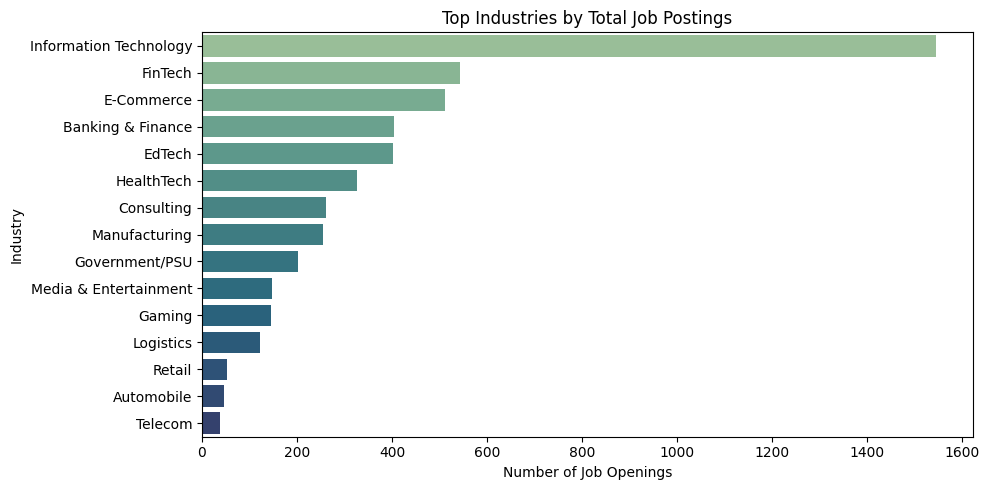

In [15]:
# 1. Count how many times each industry appears and take the top rankings
top_hiring_industries = df['Industry'].value_counts().reset_index()
top_hiring_industries.columns = ['Industry', 'Job_Count']

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_hiring_industries, x='Job_Count', y='Industry', hue='Industry', palette='crest', legend=False)
plt.title('Top Industries by Total Job Postings')
plt.xlabel('Number of Job Openings')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

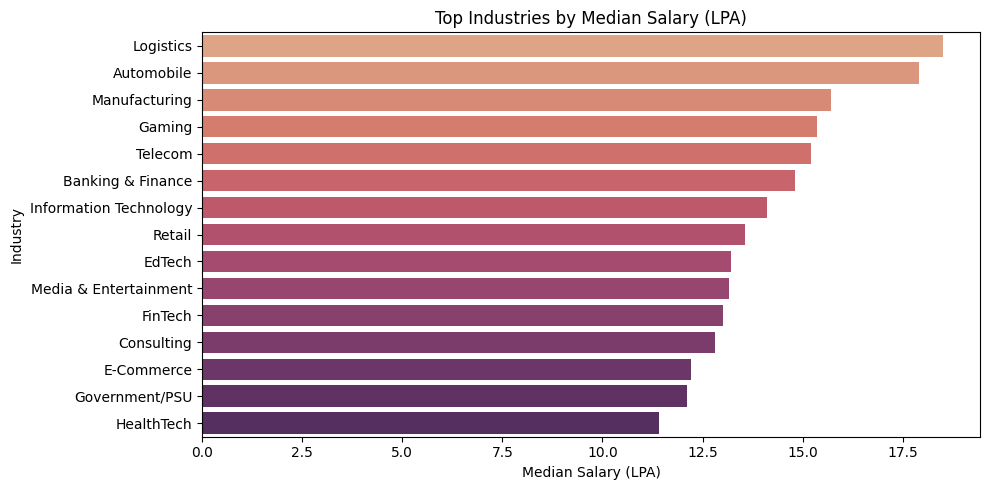

In [16]:
# 1. Group by industry, find the median salary, and sort from highest to lowest
top_industry_salaries = df.groupby('Industry')['Salary_LPA'].median().sort_values(ascending=False).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_industry_salaries, x='Salary_LPA', y='Industry', hue='Industry', palette='flare', legend=False)
plt.title('Top Industries by Median Salary (LPA)')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

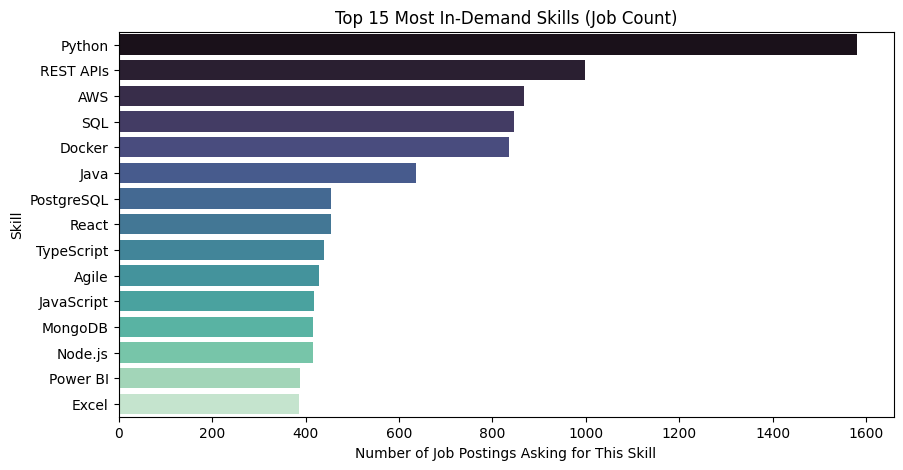

In [17]:
# 1. Split commas into lists and explode them so each skill gets its own row
df_exploded = df.assign(Skill=df['Skills_Required'].str.split(',')).explode('Skill')
df_exploded['Skill'] = df_exploded['Skill'].str.strip() # Clean up extra spaces

# 2. Count the top 15 most frequent skills
top_skills_count = df_exploded['Skill'].value_counts().head(15).reset_index()

# 3. Plot a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_skills_count, x='count', y='Skill', hue='Skill', palette='mako', legend=False)
plt.title('Top 15 Most In-Demand Skills (Job Count)')
plt.xlabel('Number of Job Postings Asking for This Skill')
plt.ylabel('Skill')
plt.show()

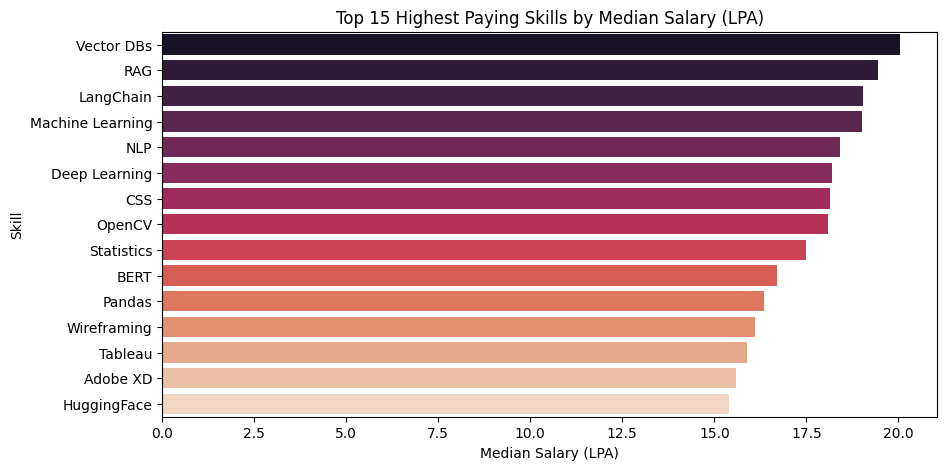

In [18]:
# 1. Group our exploded skills by name and find the median salary for each
skill_salaries = df_exploded.groupby('Skill')['Salary_LPA'].agg(['count', 'median']).reset_index()

# 2. Filter out rare skills (Only look at skills that appear at least 50 times in the data)
popular_skills = skill_salaries[skill_salaries['count'] >= 50]
top_paying_skills = popular_skills.sort_values(by='median', ascending=False).head(15)

# 3. Plot a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_paying_skills, x='median', y='Skill', hue='Skill', palette='rocket', legend=False)
plt.title('Top 15 Highest Paying Skills by Median Salary (LPA)')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('Skill')
plt.show()

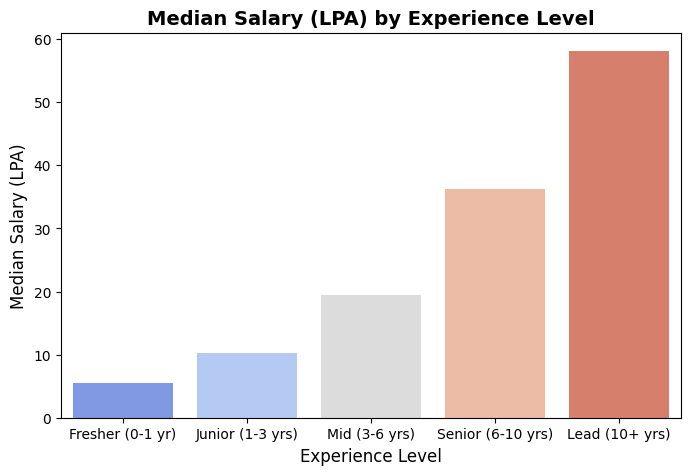

In [19]:
# 1. Group by experience level and find the median salary, sorted from lowest to highest
exp_salaries = df.groupby('Experience_Level')['Salary_LPA'].median().sort_values().reset_index()

# 2. Draw a clean, simple bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=exp_salaries, x='Experience_Level', y='Salary_LPA', hue='Experience_Level', palette='coolwarm', legend=False)

# 3. Add title and labels
plt.title('Median Salary (LPA) by Experience Level', fontsize=14, fontweight='bold')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Median Salary (LPA)', fontsize=12)
plt.show()

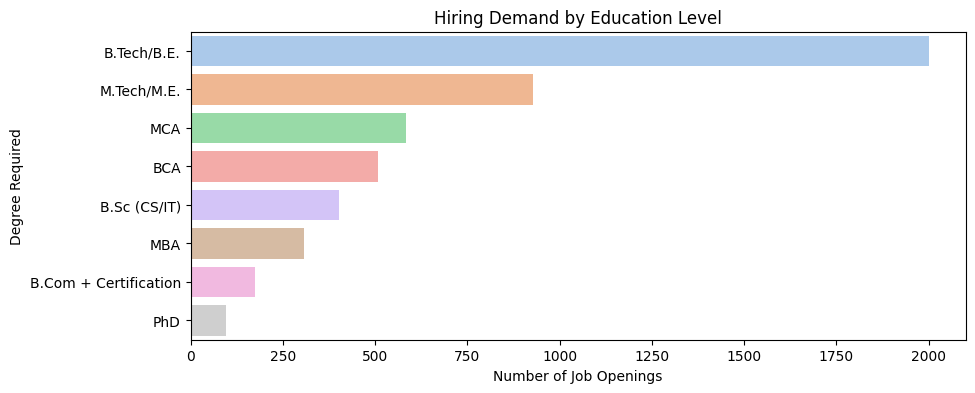

In [25]:
# 1. Count how many times each degree is required
edu_counts = df['Education_Required'].value_counts().reset_index()
edu_counts.columns = ['Education_Required', 'Job_Count']

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 4))
sns.barplot(data=edu_counts, x='Job_Count', y='Education_Required', hue='Education_Required', palette='pastel', legend=False)
plt.title('Hiring Demand by Education Level')
plt.xlabel('Number of Job Openings')
plt.ylabel('Degree Required')
plt.show()

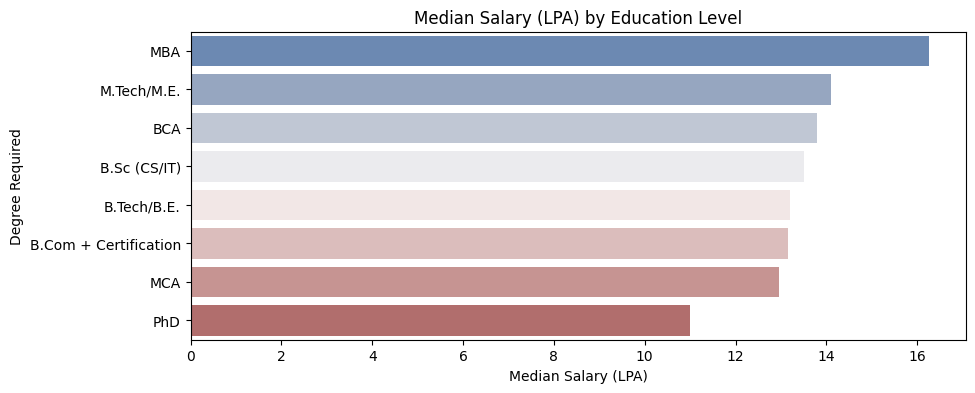

In [26]:
# 1. Group by degree and find the median salary, sorted from highest to lowest
edu_salaries = df.groupby('Education_Required')['Salary_LPA'].median().sort_values(ascending=False).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 4))
sns.barplot(data=edu_salaries, x='Salary_LPA', y='Education_Required', hue='Education_Required', palette='vlag', legend=False)
plt.title('Median Salary (LPA) by Education Level')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('Degree Required')
plt.show()

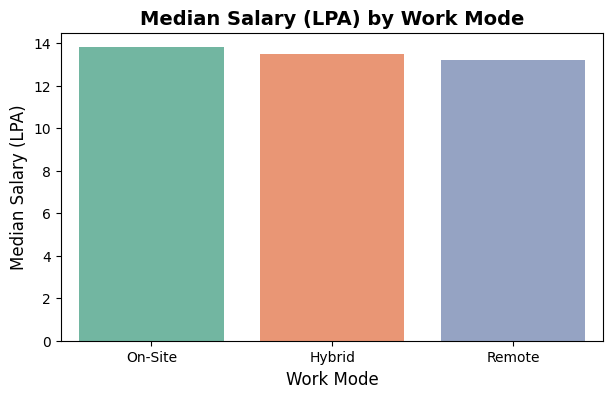

In [20]:
# 1. Group by work mode and find the median salary
work_mode_salaries = df.groupby('Work_Mode')['Salary_LPA'].median().sort_values(ascending=False).reset_index()

# 2. Draw a clean, simple bar chart
plt.figure(figsize=(7, 4))
sns.barplot(data=work_mode_salaries, x='Work_Mode', y='Salary_LPA', hue='Work_Mode', palette='Set2', legend=False)

# 3. Add titles and labels
plt.title('Median Salary (LPA) by Work Mode', fontsize=14, fontweight='bold')
plt.xlabel('Work Mode', fontsize=12)
plt.ylabel('Median Salary (LPA)', fontsize=12)
plt.show()

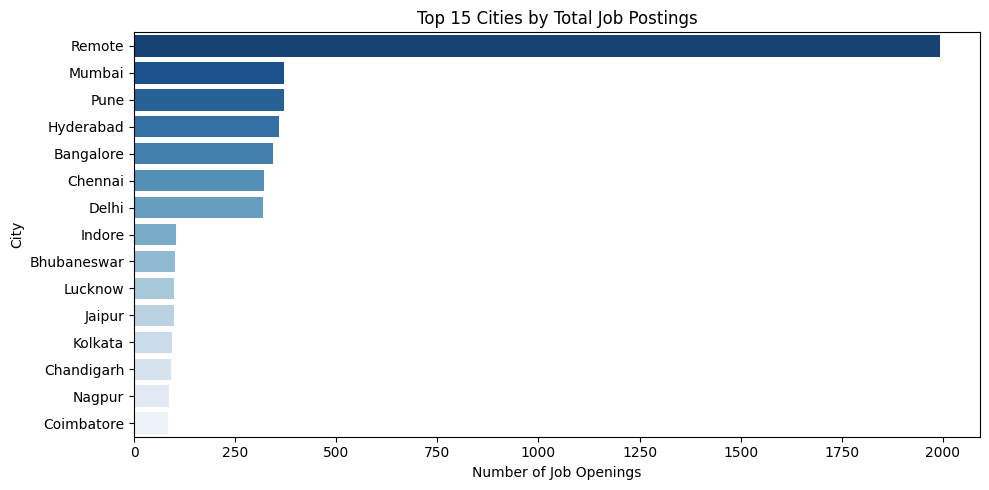

In [21]:
# 1. Count how many times each city appears and take the top 15
top_hiring_cities = df['City'].value_counts().head(15).reset_index()
top_hiring_cities.columns = ['City', 'Job_Count']

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_hiring_cities, x='Job_Count', y='City', hue='City', palette='Blues_r', legend=False)
plt.title('Top 15 Cities by Total Job Postings')
plt.xlabel('Number of Job Openings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

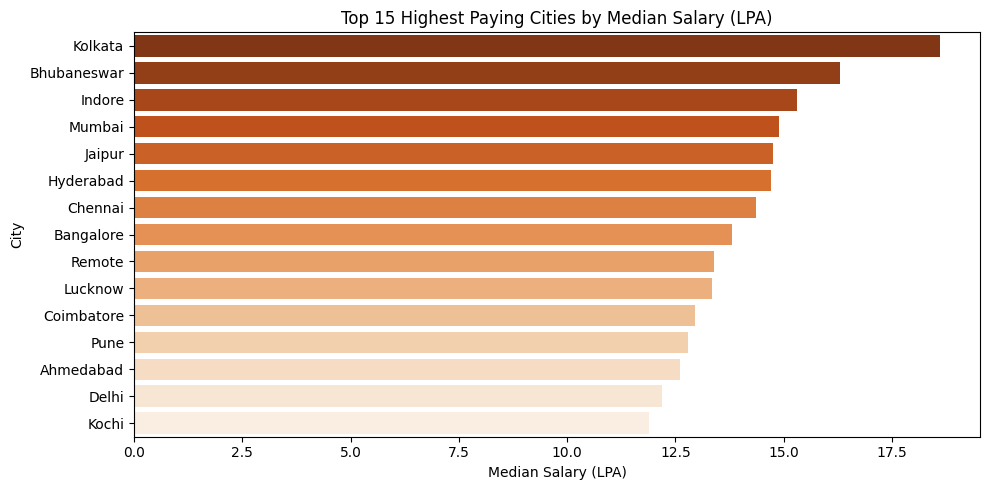

In [22]:
# 1. Group by city, find the median salary, and take the top 15
top_city_salaries = df.groupby('City')['Salary_LPA'].median().sort_values(ascending=False).head(15).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_city_salaries, x='Salary_LPA', y='City', hue='City', palette='Oranges_r', legend=False)
plt.title('Top 15 Highest Paying Cities by Median Salary (LPA)')
plt.xlabel('Median Salary (LPA)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

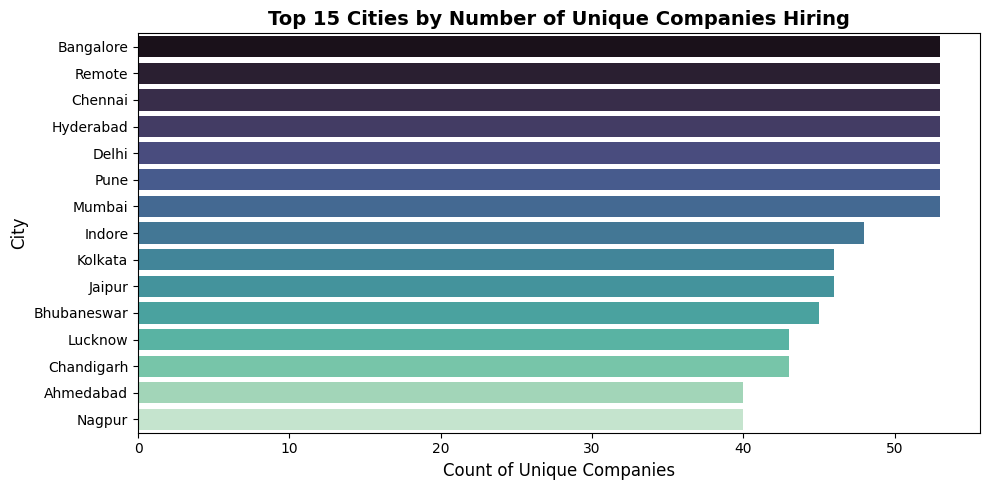

In [23]:
# 1. Count how many unique companies are active in each city and take the top 15
city_companies = df.groupby('City')['Company'].nunique().sort_values(ascending=False).head(15).reset_index()

# 2. Draw a simple horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=city_companies, x='Company', y='City', hue='City', palette='mako', legend=False)

# 3. Add titles and labels
plt.title('Top 15 Cities by Number of Unique Companies Hiring', fontsize=14, fontweight='bold')
plt.xlabel('Count of Unique Companies', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.show()